# 05a — Knowledge-Purchase Analysis

Phase 3 Tier 1.5: LLM-extracted L1/L2/L3 속성의 구매 예측 가치를 정보이론적·임베딩적으로 검증.

- **Part A**: Attribute-Purchase Mutual Information (Component A)
- **Part B**: Layer Incremental Information — CKA + Separation AUC (Component B)
- **Part C**: Preference Diversity — JSD, RVI, Temporal Stability (Component C)
- **Part D**: Synthesis — 통합 해석 + Phase 5 예측

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR = PROJECT_ROOT / 'results' / 'analysis'

LAYER_COLORS = {
    'metadata': '#4C72B0',
    'l1': '#55A868',
    'l2': '#C44E52',
    'l3': '#8172B2',
}
COMBO_COLORS = {
    'L1': '#55A868', 'L2': '#C44E52', 'L3': '#8172B2',
    'L1+L2': '#DD8452', 'L1+L3': '#937860',
    'L2+L3': '#DA8BC3', 'L1+L2+L3': '#2F2F2F',
}

## Part A: Attribute-Purchase Mutual Information

각 속성이 구매 결정을 얼마나 예측하는지 NMI + Raw MI + Conditional MI로 측정.
- 10M subsampled train pairs (pos+neg) 기반
- 메타데이터(5) vs L1(6) vs L2(6) vs L3(7) = 24개 속성

In [3]:
mi = pd.read_csv(ANALYSIS_DIR / 'mi_results.csv')
cond_mi = json.loads((ANALYSIS_DIR / 'conditional_mi.json').read_text())

print(f"Total attributes: {len(mi)}")
print(f"\nConditional MI:")
for k, v in cond_mi.items():
    print(f"  {k} = {v:.4f}")

Total attributes: 24

Conditional MI:
  MI(L2|L1) = 0.1484
  MI(L3|L1+L2) = 0.1847
  MI(L2|metadata) = 0.1397


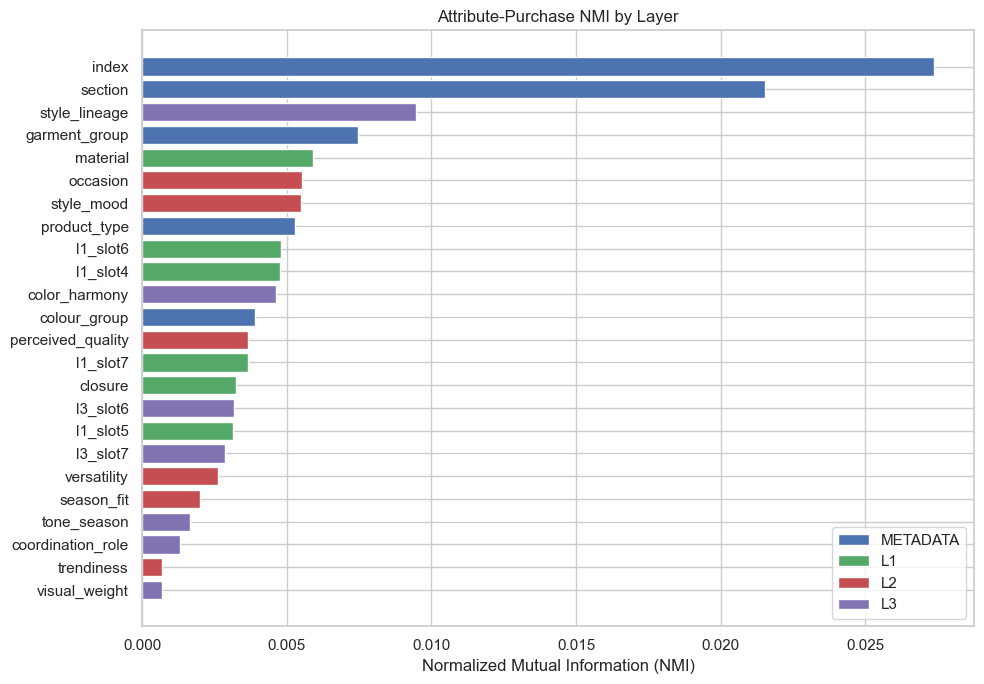

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
mi_sorted = mi.sort_values('nmi', ascending=True)
colors = [LAYER_COLORS[row['layer']] for _, row in mi_sorted.iterrows()]

ax.barh(range(len(mi_sorted)), mi_sorted['nmi'], color=colors)
ax.set_yticks(range(len(mi_sorted)))
ax.set_yticklabels(mi_sorted['attribute'])
ax.set_xlabel('Normalized Mutual Information (NMI)')
ax.set_title('Attribute-Purchase NMI by Layer')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l.upper()) for l, c in LAYER_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_nmi_by_attribute.png', dpi=150, bbox_inches='tight')
plt.show()

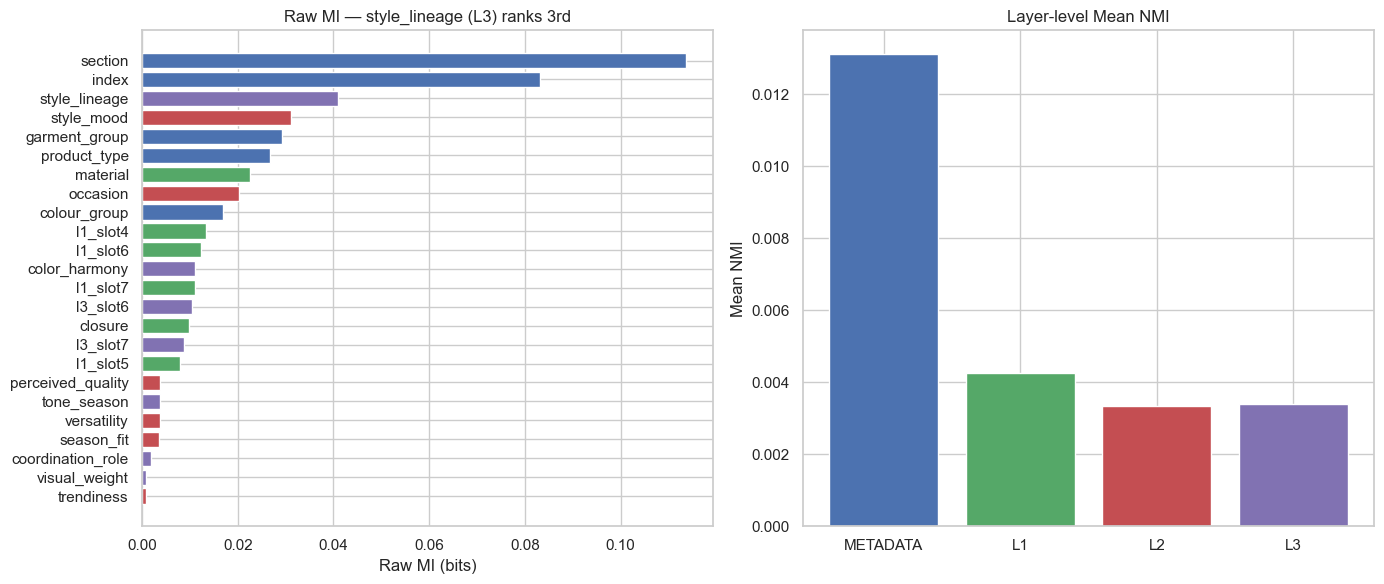

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw MI
mi_raw = mi.sort_values('mi', ascending=True)
colors_raw = [LAYER_COLORS[row['layer']] for _, row in mi_raw.iterrows()]
axes[0].barh(range(len(mi_raw)), mi_raw['mi'], color=colors_raw)
axes[0].set_yticks(range(len(mi_raw)))
axes[0].set_yticklabels(mi_raw['attribute'])
axes[0].set_xlabel('Raw MI (bits)')
axes[0].set_title('Raw MI — style_lineage (L3) ranks 3rd')

# Layer-level summary
layer_summary = mi.groupby('layer').agg(
    mean_nmi=('nmi', 'mean'), max_nmi=('nmi', 'max'), mean_mi=('mi', 'mean'),
).reindex(['metadata', 'l1', 'l2', 'l3'])
x = range(len(layer_summary))
axes[1].bar(x, layer_summary['mean_nmi'], color=[LAYER_COLORS[l] for l in layer_summary.index])
axes[1].set_xticks(x)
axes[1].set_xticklabels([l.upper() for l in layer_summary.index])
axes[1].set_ylabel('Mean NMI')
axes[1].set_title('Layer-level Mean NMI')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_mi_raw_and_layer_summary.png', dpi=150, bbox_inches='tight')
plt.show()

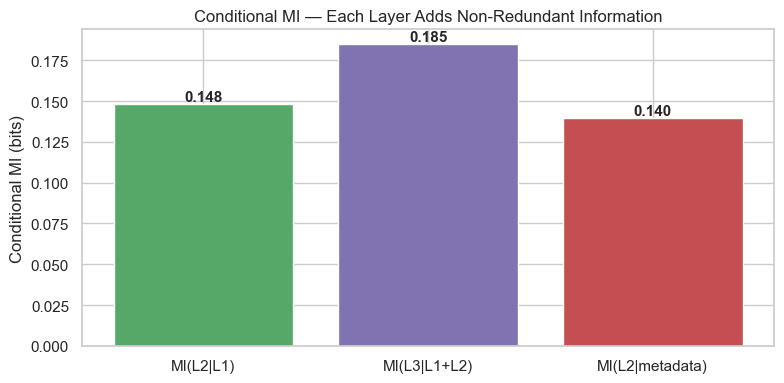

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
cond_labels = list(cond_mi.keys())
cond_values = list(cond_mi.values())
bars = ax.bar(range(len(cond_labels)), cond_values, color=['#55A868', '#8172B2', '#C44E52'])
ax.set_xticks(range(len(cond_labels)))
ax.set_xticklabels(cond_labels, fontsize=11)
ax.set_ylabel('Conditional MI (bits)')
ax.set_title('Conditional MI — Each Layer Adds Non-Redundant Information')

for bar, val in zip(bars, cond_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_conditional_mi.png', dpi=150, bbox_inches='tight')
plt.show()

### Part A Findings

1. **NMI**: metadata(index, section)가 개별 속성으로 최고. 하지만 고-카디널리티 L2/L3는 NMI 분모(H(A))가 커서 불리
2. **Raw MI**: style_lineage(L3) 전체 3위, style_mood(L2) 4위 — L2/L3가 실질적으로 강한 구매 시그널
3. **Conditional MI**: MI(L3|L1+L2)=0.185 > MI(L2|L1)=0.148 → **L3가 가장 큰 비중복 정보 추가**
4. **해석**: 각 Layer가 이전 Layer에 없는 고유한 구매 예측 정보를 포함 → 3-Layer Taxonomy 정당화

## Part B: Layer Incremental Information (CKA + Separation AUC)

BGE 임베딩 공간에서 7종 ablation 변형 간 표현 유사도(CKA)와 구매-비구매 분리도(AUC) 비교.

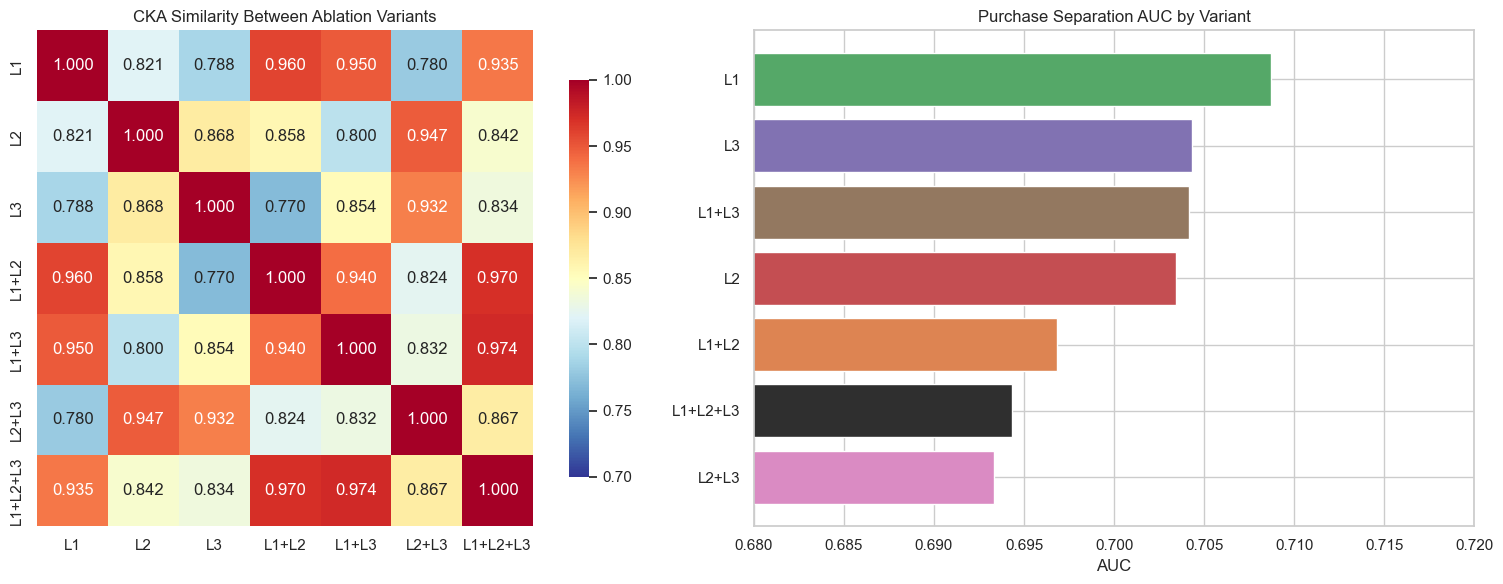

In [7]:
cka = pd.read_csv(ANALYSIS_DIR / 'cka_matrix.csv', index_col=0)
auc = pd.read_csv(ANALYSIS_DIR / 'separation_auc.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CKA heatmap
combo_order = ['L1', 'L2', 'L3', 'L1+L2', 'L1+L3', 'L2+L3', 'L1+L2+L3']
cka_ordered = cka.reindex(combo_order, axis=0).reindex(combo_order, axis=1)
sns.heatmap(cka_ordered, annot=True, fmt='.3f', cmap='RdYlBu_r', vmin=0.7, vmax=1.0,
            ax=axes[0], square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('CKA Similarity Between Ablation Variants')

# Separation AUC
auc_sorted = auc.sort_values('auc', ascending=True)
axes[1].barh(range(len(auc_sorted)), auc_sorted['auc'],
             color=[COMBO_COLORS.get(c, '#666') for c in auc_sorted['layer_combo']])
axes[1].set_yticks(range(len(auc_sorted)))
axes[1].set_yticklabels(auc_sorted['layer_combo'])
axes[1].set_xlabel('AUC')
axes[1].set_title('Purchase Separation AUC by Variant')
axes[1].set_xlim(0.68, 0.72)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_cka_and_auc.png', dpi=150, bbox_inches='tight')
plt.show()

### Part B Findings

1. **CKA**: L1↔L3=0.788 (최대 차이), L2↔L3=0.868 → 3개 Layer가 서로 다른 표현 학습
2. **L1 추가 효과**: CKA(L2+L3, L1+L2+L3)=0.867 → L1이 13.3%의 표현 변화 유도 (가장 큼)
3. **Separation AUC**: 모든 변형이 0.69-0.71로 비슷 → 순수 cosine 유사도만으로는 변형 간 차이가 미미
4. **해석**: Layer간 표현 차이는 존재하나, KAR Expert의 non-linear 변환이 이를 증폭시켜야 함

## Part C: Preference Diversity

클러스터링 없이 속성별 유저 간 선호 차별화를 직접 측정.
- RVI (Recommendation Value Index) = JSD / entropy
- Temporal stability: 전반기/후반기 분포 cosine

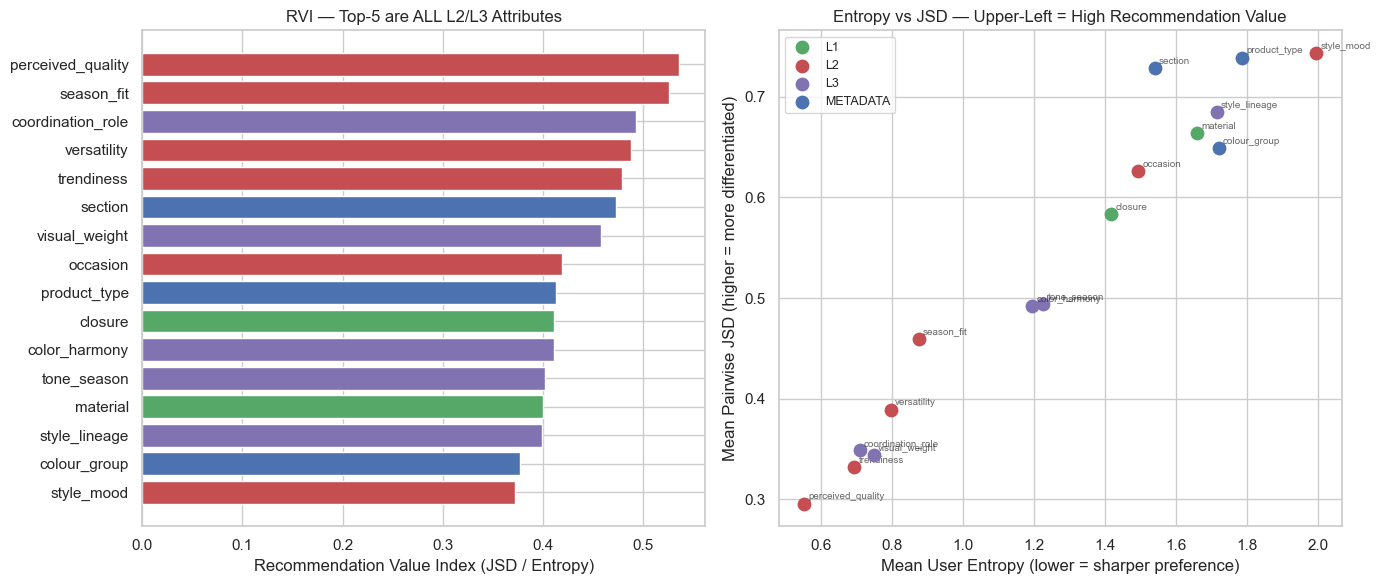

In [8]:
div = pd.read_csv(ANALYSIS_DIR / 'diversity_results.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RVI bar chart
div_sorted = div.sort_values('recommendation_value_index', ascending=True)
colors_div = [LAYER_COLORS[row['layer']] for _, row in div_sorted.iterrows()]
axes[0].barh(range(len(div_sorted)), div_sorted['recommendation_value_index'], color=colors_div)
axes[0].set_yticks(range(len(div_sorted)))
axes[0].set_yticklabels(div_sorted['attribute'])
axes[0].set_xlabel('Recommendation Value Index (JSD / Entropy)')
axes[0].set_title('RVI — Top-5 are ALL L2/L3 Attributes')

# Entropy vs JSD scatter
for layer, group in div.groupby('layer'):
    axes[1].scatter(group['mean_user_entropy'], group['mean_pairwise_jsd'],
                   c=LAYER_COLORS[layer], s=80, label=layer.upper(), zorder=3)
    for _, row in group.iterrows():
        axes[1].annotate(row['attribute'], (row['mean_user_entropy'], row['mean_pairwise_jsd']),
                        fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
axes[1].set_xlabel('Mean User Entropy (lower = sharper preference)')
axes[1].set_ylabel('Mean Pairwise JSD (higher = more differentiated)')
axes[1].set_title('Entropy vs JSD — Upper-Left = High Recommendation Value')
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_diversity_rvi_and_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

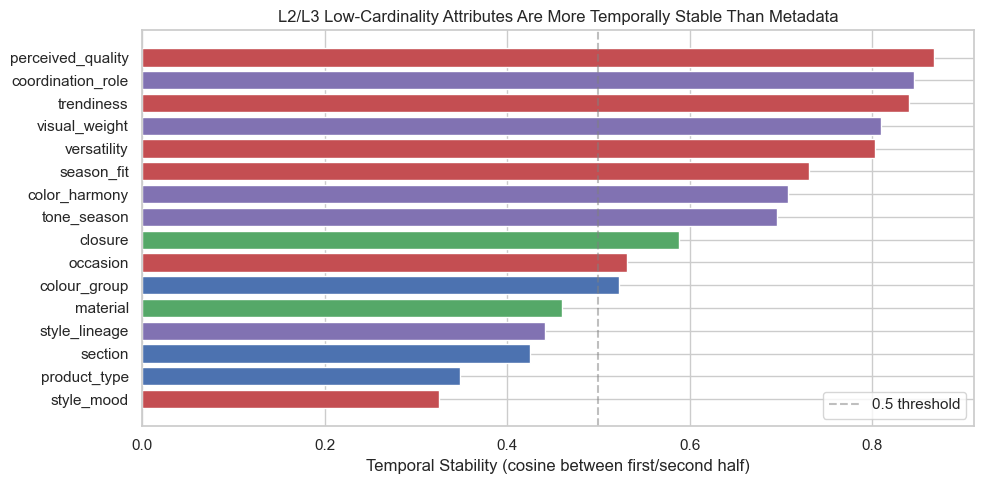

In [9]:
# Temporal stability comparison
fig, ax = plt.subplots(figsize=(10, 5))
div_stab = div.sort_values('temporal_stability', ascending=True)
colors_stab = [LAYER_COLORS[row['layer']] for _, row in div_stab.iterrows()]
ax.barh(range(len(div_stab)), div_stab['temporal_stability'], color=colors_stab)
ax.set_yticks(range(len(div_stab)))
ax.set_yticklabels(div_stab['attribute'])
ax.set_xlabel('Temporal Stability (cosine between first/second half)')
ax.set_title('L2/L3 Low-Cardinality Attributes Are More Temporally Stable Than Metadata')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05a_temporal_stability.png', dpi=150, bbox_inches='tight')
plt.show()

### Part C Findings

1. **RVI Top-5 전부 L2/L3**: perceived_quality(0.535), season_fit(0.525), coordination_role(0.492)
2. **시간 안정성**: L2/L3 저-카디널리티 속성(0.80-0.87) > 메타데이터(0.35-0.52)
3. **해석**: L2/L3가 포착하는 선호(품질 기대치, 계절 선호, 코디 역할)는 근본적 취향 — 시간이 지나도 안정
4. **vs 세그멘테이션**: 유저-레벨 클러스터링은 CLT 붕괴로 실패했지만, 속성-레벨 직접 측정은 선호 차별화를 명확히 포착

## Part D: Synthesis — 통합 해석

### Research Question 답변

> "LLM 추출 L2/L3가 기존 메타데이터 대비 증분 가치를 제공하는가?"

**YES.**

| 증거 | 수치 |
|------|------|
| Conditional MI(L3\|L1+L2) | 0.185 (가장 큰 비중복 정보) |
| Raw MI: style_lineage(L3) | 전체 3위 (0.041) |
| RVI Top-5 | 전부 L2/L3 |
| Temporal stability | L2/L3 > metadata (0.80+ vs 0.35-0.52) |
| CKA(L1, L3) | 0.788 (서로 다른 표현 학습) |

### Phase 5 Ablation 예측

Layer ablation에서 L1+L2 조합이 가장 강할 것으로 예측:
- L1이 가장 강한 개별 content-based 시그널 (NMI 최고)
- L2가 가장 높은 추천 가치 (RVI top)
- L3는 비중복 정보가 가장 크므로 L1+L2+L3이 L1+L2를 개선할 가능성

단, KAR Expert의 non-linear 변환이 순수 cosine보다 더 큰 차이를 만들어야 함 (AUC가 0.69-0.71로 비슷하므로).

In [10]:
# Summary table
summary = pd.DataFrame({
    'Metric': ['Conditional MI(L2|L1)', 'Conditional MI(L3|L1+L2)',
               'Raw MI Top L2/L3', 'RVI Top-1 (L2)',
               'Temporal Stability (L2 avg)', 'CKA(L1, L3)'],
    'Value': [f"{cond_mi['MI(L2|L1)']:.3f}",
              f"{cond_mi['MI(L3|L1+L2)']:.3f}",
              f"style_lineage: {mi[mi.attribute=='style_lineage']['mi'].values[0]:.3f}",
              f"perceived_quality: {div[div.attribute=='perceived_quality']['recommendation_value_index'].values[0]:.3f}",
              f"{div[div.layer=='l2']['temporal_stability'].mean():.3f}",
              f"{cka.loc['L1', 'L3']:.3f}"],
    'Interpretation': [
        'L2 adds info beyond L1',
        'L3 adds MOST non-redundant info',
        'L3 attribute ranks 3rd overall in raw MI',
        'L2 attribute has highest recommendation value',
        'L2 captures stable deep preferences',
        'L1 and L3 encode different representations',
    ],
})
print(summary.to_string(index=False))

                     Metric                    Value                                Interpretation
      Conditional MI(L2|L1)                    0.148                        L2 adds info beyond L1
   Conditional MI(L3|L1+L2)                    0.185               L3 adds MOST non-redundant info
           Raw MI Top L2/L3     style_lineage: 0.041      L3 attribute ranks 3rd overall in raw MI
             RVI Top-1 (L2) perceived_quality: 0.535 L2 attribute has highest recommendation value
Temporal Stability (L2 avg)                    0.683           L2 captures stable deep preferences
                CKA(L1, L3)                    0.788    L1 and L3 encode different representations
